In [41]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import json, os
import joblib
from itertools import product
from scipy.signal import butter, filtfilt

import matplotlib.ticker as mticker
import pandas as pd
import control as ctl

In [42]:
OPTIONS = json.loads(open('info.json', 'r').read())
OPTIONS

{'dt': 0.048,
 'offset': 22,
 'view_range': [0.7, 0.8],
 'sensor_range': [0, 0.3],
 'actuator_range': [45, 135],
 'sensor_filter': {'num': [0.18446880939648136, 0.1844688093964813],
  'den': [1.0, -0.6310623812070374]},
 'actuator_std': 1.5155531528061452,
 'max_action': 10.0,
 'ts': 7.7184}

In [43]:
df   = pd.read_csv('../Dataset/data_cleaned.csv')
K_CV = 5
TEMPORAL = True

X_MIN, X_MAX = OPTIONS.get('view_range')
dt = OPTIONS.get('dt')
ts = OPTIONS.get('ts')
OFFSET = OPTIONS.get('offset')
df

,time,input,sensor
0,0.000,85,0.031729
1,0.048,75,0.082558
2,0.096,70,0.114818
3,0.144,65,0.136468
4,0.192,60,0.149946
...,...,...,...
10387,498.576,130,0.009000
10388,498.624,130,0.009000
10389,498.672,130,0.009000
10390,498.720,130,0.009000


Text(0, 0.5, 'sensor')

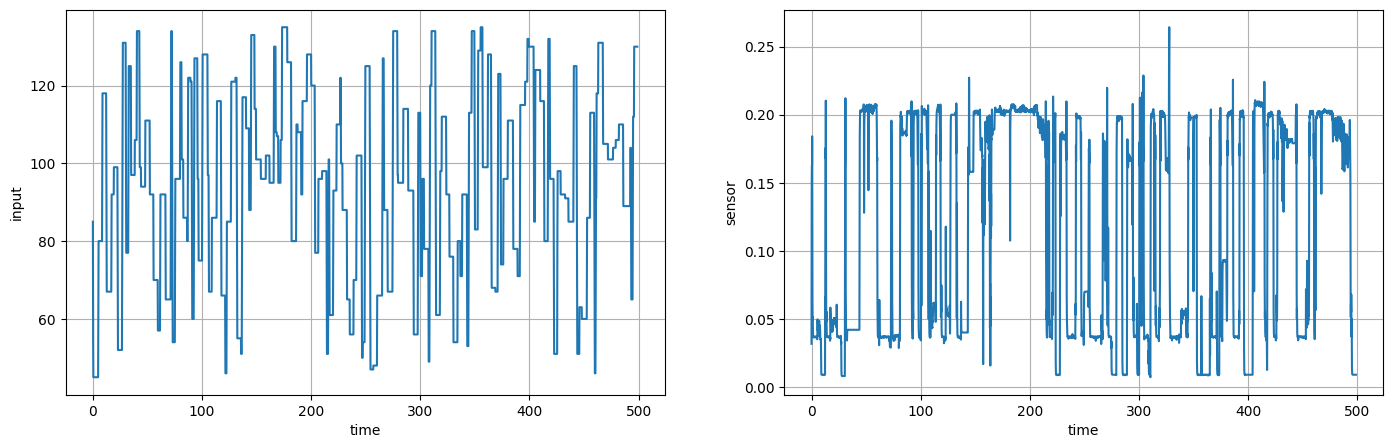

In [44]:
plt.figure(figsize=(17, 5))
plt.subplot(1, 2, 1)
plt.plot(df.time, df.input)
plt.grid()
plt.xlabel('time'); plt.ylabel('input')

plt.subplot(1, 2, 2)
plt.plot(df.time, df.sensor)
plt.grid()
plt.xlabel('time'); plt.ylabel('sensor')

In [45]:
def getStates(df, key, var='y', n=10, last=True):
    table = df.copy() 
    table[f'{var}'] = table[key]

    for i in range(1, n):
        table[f'{var}(n-{i})'] = table[key].shift(i)

    table.fillna(0, inplace=True)
    columns = [f'{var}'] + [f'{var}(n-{i})' for i in range(1, n)]

    if not last:
        columns = columns[1:]

    return table[columns]


N_STATES = OFFSET + 5
xData    = pd.concat([
    getStates(df, 'input',  var='u', n=N_STATES, last=True), 
    getStates(df, 'sensor', var='x', n=N_STATES, last=False)
], axis=1)

xData = xData.iloc[N_STATES:].reset_index(drop=True)
yData = df.sensor.values[N_STATES:]
xData

,u,u(n-1),u(n-2),u(n-3),u(n-4),u(n-5),u(n-6),u(n-7),u(n-8),u(n-9),...,x(n-17),x(n-18),x(n-19),x(n-20),x(n-21),x(n-22),x(n-23),x(n-24),x(n-25),x(n-26)
0,45,45.0,45.0,45.0,45.0,45.0,45.0,45.0,45.0,45.0,...,0.162712,0.161667,0.162350,0.161969,0.160490,0.156976,0.149946,0.136468,0.114818,0.082558
1,45,45.0,45.0,45.0,45.0,45.0,45.0,45.0,45.0,45.0,...,0.166323,0.162712,0.161667,0.162350,0.161969,0.160490,0.156976,0.149946,0.136468,0.114818
2,45,45.0,45.0,45.0,45.0,45.0,45.0,45.0,45.0,45.0,...,0.184098,0.166323,0.162712,0.161667,0.162350,0.161969,0.160490,0.156976,0.149946,0.136468
3,45,45.0,45.0,45.0,45.0,45.0,45.0,45.0,45.0,45.0,...,0.181110,0.184098,0.166323,0.162712,0.161667,0.162350,0.161969,0.160490,0.156976,0.149946
4,45,45.0,45.0,45.0,45.0,45.0,45.0,45.0,45.0,45.0,...,0.145098,0.181110,0.184098,0.166323,0.162712,0.161667,0.162350,0.161969,0.160490,0.156976
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10360,130,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,...,0.009000,0.009000,0.009000,0.009000,0.009000,0.009000,0.009000,0.009000,0.009000,0.009000
10361,130,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,...,0.009000,0.009000,0.009000,0.009000,0.009000,0.009000,0.009000,0.009000,0.009000,0.009000
10362,130,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,...,0.009000,0.009000,0.009000,0.009000,0.009000,0.009000,0.009000,0.009000,0.009000,0.009000
10363,130,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,...,0.009000,0.009000,0.009000,0.009000,0.009000,0.009000,0.009000,0.009000,0.009000,0.009000


In [46]:
from Selector.index import ModelSelector

In [47]:
selector = ModelSelector('linear_regression')
model, params = selector.get()
model

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [48]:
from GridSearch.index import GridSearch

In [49]:
grid = GridSearch(model, params, xData, yData, K_CV, temporal=TEMPORAL)
grid.update()

model, r2_adj = grid.evaluate()
print('best_R2_Adjusted:', r2_adj)
model

Fitting 5 folds for each of 4 candidates, totalling 20 fits
best_R2_Adjusted: 0.9976231072215632


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [50]:
from Metrics.CrossValidation.index import CrossValidation
from Metrics.GaussianAnalyser.index import GaussianAnalyser

In [51]:
cross = CrossValidation(model, xData, yData, K_CV, temporal=TEMPORAL)
cross.update()

if not TEMPORAL:
    analyser = GaussianAnalyser(cross)
    analyser.update()
    analyser.plot()
    analyser.info()

In [52]:
from Metrics.Plotter.index import Plotter

In [53]:
cross.print()

R2: 0.9963 (±0.0018) [Erro Absoluto]
R2_ADJ: 0.9962 (±0.0018) [Erro Absoluto]
RMSE: 0.0043 (±0.0009) [Erro Absoluto]
MAE: 0.0017 (±0.0004) [Erro Absoluto]


,name,values,mean,std,min,max,split_1,split_2,split_3,split_4,split_5
0,R2,"[0.9931191033221061, 0.9977224083178424, 0.995...",0.996274,0.001768,0.993119,0.997722,0.993119,0.997722,0.995524,0.997449,0.997555
1,R2_ADJ,"[0.9929011191476121, 0.997650255084636, 0.9953...",0.996156,0.001824,0.992901,0.997650,0.992901,0.997650,0.995382,0.997368,0.997478
2,RMSE,"[0.0058375300677901264, 0.0033681300122116423,...",0.004317,0.000936,0.003368,0.005838,0.005838,0.003368,0.004865,0.004101,0.003412
3,MAE,"[0.002232044846628798, 0.001284807690408379, 0...",0.001684,0.000358,0.001285,0.002232,0.002232,0.001285,0.001948,0.001591,0.001362


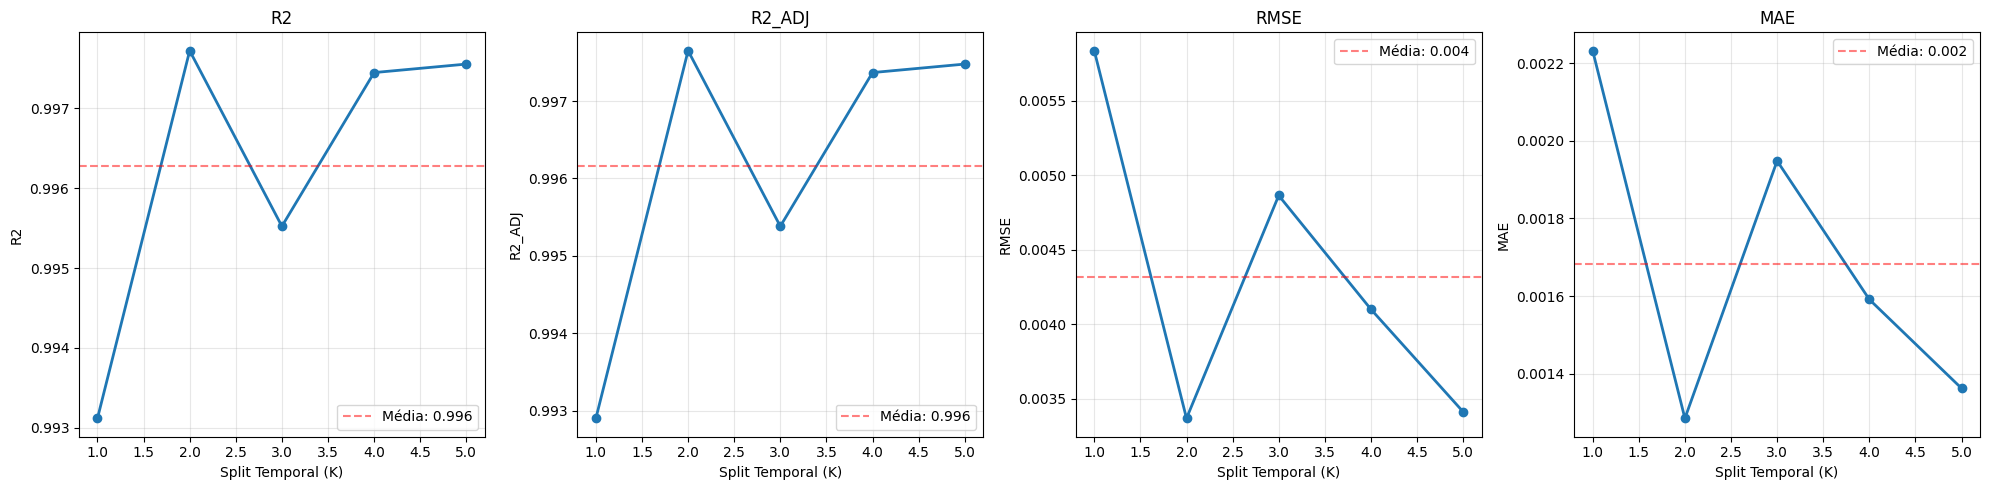

In [54]:
cross.plot()

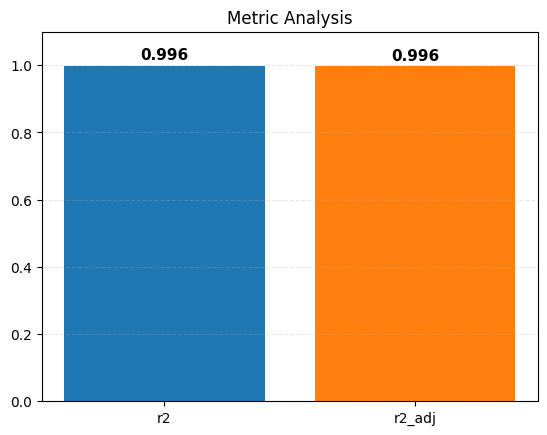

In [55]:
info = {'r2': cross.r2, 'r2_adj': cross.adj_r2}
Plotter(info)

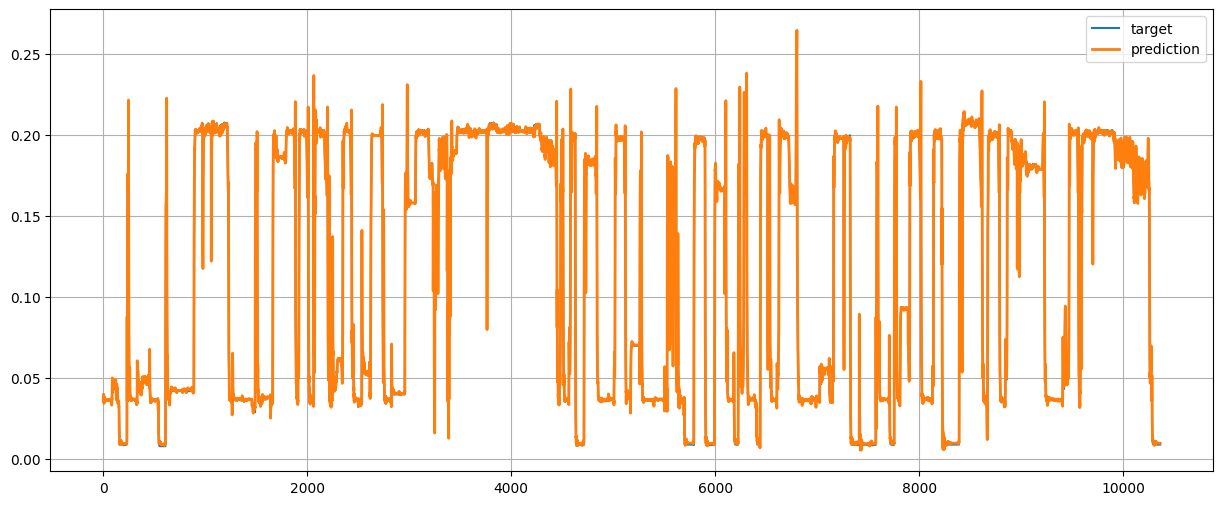

In [56]:
plt.figure(figsize=(15, 6))
plt.plot(yData, label='target')
plt.plot(model.predict(xData), label='prediction', linewidth=2)
plt.grid(); plt.legend()
plt.show()

In [57]:
model.fit(xData, yData)
model.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()), ('model', LinearRegression())],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(),
 'model': LinearRegression(),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'model__copy_X': True,
 'model__fit_intercept': True,
 'model__n_jobs': None,
 'model__positive': False,
 'model__tol': 1e-06}

In [58]:
model

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [59]:
results = {
    'model': selector.chosen,
    'params': {key: str(value) for key, value in model.get_params().items()},
    'K_CV': K_CV,
    'info': analyser.info() if not TEMPORAL else cross.info(),
    'variables': xData.columns.tolist()
}

display(pd.DataFrame([results.get('info')]))
results

,r2,r2_adj,rmse,mae
0,0.996274,0.996156,0.004317,0.001684


{'model': 'linear_regression',
 'params': {'memory': 'None',
  'steps': "[('scaler', StandardScaler()), ('model', LinearRegression())]",
  'transform_input': 'None',
  'verbose': 'False',
  'scaler': 'StandardScaler()',
  'model': 'LinearRegression()',
  'scaler__copy': 'True',
  'scaler__with_mean': 'True',
  'scaler__with_std': 'True',
  'model__copy_X': 'True',
  'model__fit_intercept': 'True',
  'model__n_jobs': 'None',
  'model__positive': 'False',
  'model__tol': '1e-06'},
 'K_CV': 5,
 'info': {'r2': 0.996273813121768,
  'r2_adj': 0.9961557689469048,
  'rmse': 0.004316652752266345,
  'mae': 0.001683661244121807},
 'variables': ['u',
  'u(n-1)',
  'u(n-2)',
  'u(n-3)',
  'u(n-4)',
  'u(n-5)',
  'u(n-6)',
  'u(n-7)',
  'u(n-8)',
  'u(n-9)',
  'u(n-10)',
  'u(n-11)',
  'u(n-12)',
  'u(n-13)',
  'u(n-14)',
  'u(n-15)',
  'u(n-16)',
  'u(n-17)',
  'u(n-18)',
  'u(n-19)',
  'u(n-20)',
  'u(n-21)',
  'u(n-22)',
  'u(n-23)',
  'u(n-24)',
  'u(n-25)',
  'u(n-26)',
  'x(n-1)',
  'x(n-2)',


In [60]:
os.makedirs('Saved/System', exist_ok=True)
output = f'Saved/System/'
os.makedirs(output, exist_ok=True)

pd.Series(results).to_json(os.path.join(output, 'info.json'), indent=4)
joblib.dump(model, os.path.join(output, 'model.pkl'))

['Saved/System/model.pkl']